# 02 - Preparación de Datos para Forecasting

## 1. Objetivo, contexto de negocio, qué se consigue al finalizar

### Objetivo
Transformar y unificar los tres archivos de datos (ventas, calendario, precios) en un único dataset limpio y estructurado, listo para análisis de series temporales y modelado.

### Contexto de negocio
Para predecir ventas a nivel tienda-producto, necesitamos un dataset donde cada fila represente una observación diaria con toda la información relevante: ventas, fecha, características del producto, tienda y precio. Esto permitirá crear features temporales y entrenar modelos de forecasting.

### Qué se consigue al finalizar
- Dataset en formato long (una fila por producto-tienda-día)
- Anomalías investigadas y resueltas (duplicados y nulos en prices)
- Tablas unificadas con información de ventas, calendario y precios
- Archivo procesado guardado para usar en notebooks posteriores

## 2. Importación de librerías

In [2]:
import pandas as pd
import numpy as np
import warnings
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway


# Configuración
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 3. Carga de datos

Cargamos los tres archivos CSV desde sus rutas originales.

In [3]:
# Rutas de los archivos
ITEM_SALES = pd.read_csv('/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/raw/item_sales.csv')
CALENDAR = pd.read_csv('/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/raw/daily_calendar_with_events.csv')
ITEM_PRICES = pd.read_csv('/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/raw/item_prices.csv')

print("Datos cargados correctamente")
print(f"- item_sales: {ITEM_SALES.shape[0]:,} filas x {ITEM_SALES.shape[1]} columnas")
print(f"- calendar: {CALENDAR.shape[0]:,} filas x {CALENDAR.shape[1]} columnas")
print(f"- item_prices: {ITEM_PRICES.shape[0]:,} filas x {ITEM_PRICES.shape[1]} columnas")

Datos cargados correctamente
- item_sales: 30,490 filas x 1920 columnas
- calendar: 1,913 filas x 5 columnas
- item_prices: 6,965,706 filas x 5 columnas


## 4. Transformación de item_sales (wide → long)

El archivo `item_sales` tiene formato wide: cada columna `d_1`, `d_2`, ..., `d_1913` representa las ventas de un día. Necesitamos transformarlo a formato long donde cada fila sea una observación producto-tienda-día.

**Antes (wide):**
| id | item | store | d_1 | d_2 | ... |
|----|------|-------|-----|-----|-----|
| X  | A    | NYC   | 5   | 3   | ... |

**Después (long):**
| id | item | store | d    | sales |
|----|------|-------|------|-------|
| X  | A    | NYC   | d_1  | 5     |
| X  | A    | NYC   | d_2  | 3     |

In [4]:
# Identificar columnas de identificación y columnas de días
cols_info = ['id', 'item', 'category', 'department', 'store', 'store_code', 'region']
cols_dias = [col for col in ITEM_SALES.columns if col.startswith('d_')]

print(f"Columnas de identificación: {len(cols_info)}")
print(f"Columnas de días (ventas): {len(cols_dias)}")

Columnas de identificación: 7
Columnas de días (ventas): 1913


In [5]:
# Transformar de wide a long usando melt (puede tardar por tamaño de los datos)

print("Transformando datos de wide a long...")
print("(Esto puede tardar ~1 minuto)")

sales_long = ITEM_SALES.melt(
    id_vars=cols_info,
    value_vars=cols_dias,
    var_name='d',
    value_name='sales'
)

print(f"\nTransformación completada")
print(f"Dimensiones: {sales_long.shape[0]:,} filas x {sales_long.shape[1]} columnas")
print(f"Filas esperadas: {ITEM_SALES.shape[0]:,} series x {len(cols_dias)} días = {ITEM_SALES.shape[0] * len(cols_dias):,}")

Transformando datos de wide a long...
(Esto puede tardar ~1 minuto)

Transformación completada
Dimensiones: 58,327,370 filas x 9 columnas
Filas esperadas: 30,490 series x 1913 días = 58,327,370


In [6]:
# Verificar resultado
print("Primeras filas del dataset transformado:")
sales_long.head(10)

Primeras filas del dataset transformado:


,id,item,category,department,store,store_code,region,d,sales
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
3,ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
5,ACCESORIES_1_006_NYC_1,ACCESORIES_1_006,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
6,ACCESORIES_1_007_NYC_1,ACCESORIES_1_007,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
7,ACCESORIES_1_008_NYC_1,ACCESORIES_1_008,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,12
8,ACCESORIES_1_009_NYC_1,ACCESORIES_1_009,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,2
9,ACCESORIES_1_010_NYC_1,ACCESORIES_1_010,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0


In [7]:
# Verificar tipos de datos
print("Tipos de datos:")
print(sales_long.dtypes)

Tipos de datos:
id            object
item          object
category      object
department    object
store         object
store_code    object
region        object
d             object
sales          int64
dtype: object


## 5. Investigación de anomalías en item_prices

En el notebook anterior detectamos:
- **213,430 duplicados** por combinación item + store_code + yearweek
- **243,920 nulos** en la columna yearweek

Vamos a investigar estas anomalías antes de decidir cómo tratarlas.

In [8]:
# Investigar duplicados
print("="*60)
print("INVESTIGACIÓN DE DUPLICADOS EN ITEM_PRICES")
print("="*60)

# Encontrar registros duplicados
duplicados = ITEM_PRICES[ITEM_PRICES.duplicated(subset=['item', 'store_code', 'yearweek'], keep=False)]
print(f"Registros involucrados en duplicados: {len(duplicados):,}")

# Ver algunos ejemplos
print("\nEjemplos de duplicados:")
ejemplo_dup = duplicados.groupby(['item', 'store_code', 'yearweek']).head(5)
print(ejemplo_dup.head(20))

INVESTIGACIÓN DE DUPLICADOS EN ITEM_PRICES
Registros involucrados en duplicados: 243,920

Ejemplos de duplicados:
Empty DataFrame
Columns: [item, category, store_code, yearweek, sell_price]
Index: []


In [9]:
# ¿Los duplicados tienen el mismo precio o diferente?
print("="*60)
print("¿LOS DUPLICADOS TIENEN PRECIOS DIFERENTES?")
print("="*60)

# Agrupar por item, store_code, yearweek y contar precios únicos
precios_por_grupo = ITEM_PRICES.groupby(['item', 'store_code', 'yearweek'])['sell_price'].nunique()
grupos_con_multiples_precios = (precios_por_grupo > 1).sum()

print(f"Grupos con más de un precio: {grupos_con_multiples_precios:,}")
print(f"Grupos con un solo precio: {(precios_por_grupo == 1).sum():,}")

if grupos_con_multiples_precios > 0:
    print("\nEjemplos de grupos con múltiples precios:")
    grupos_multiples = precios_por_grupo[precios_por_grupo > 1].head(5).index.tolist()
    for grupo in grupos_multiples[:3]:
        item, store, week = grupo
        subset = ITEM_PRICES[(ITEM_PRICES['item'] == item) & 
                            (ITEM_PRICES['store_code'] == store) & 
                            (ITEM_PRICES['yearweek'] == week)]
        print(f"\n{item} - {store} - {week}:")
        print(subset)

¿LOS DUPLICADOS TIENEN PRECIOS DIFERENTES?
Grupos con más de un precio: 0
Grupos con un solo precio: 6,721,786


In [10]:
# Investigar nulos en yearweek
print("="*60)
print("INVESTIGACIÓN DE NULOS EN YEARWEEK")
print("="*60)

nulos_yearweek = ITEM_PRICES[ITEM_PRICES['yearweek'].isna()]
print(f"Registros con yearweek nulo: {len(nulos_yearweek):,}")

print("\nEjemplos de registros con yearweek nulo:")
print(nulos_yearweek.head(10))

print("\n¿Tienen precio estos registros?")
print(nulos_yearweek['sell_price'].describe())

INVESTIGACIÓN DE NULOS EN YEARWEEK
Registros con yearweek nulo: 243,920

Ejemplos de registros con yearweek nulo:
                 item    category store_code  yearweek  sell_price
149  ACCESORIES_1_001  ACCESORIES      NYC_1       NaN       11.15
150  ACCESORIES_1_001  ACCESORIES      NYC_1       NaN       11.15
151  ACCESORIES_1_001  ACCESORIES      NYC_1       NaN       11.15
152  ACCESORIES_1_001  ACCESORIES      NYC_1       NaN       11.15
153  ACCESORIES_1_001  ACCESORIES      NYC_1       NaN       11.15
154  ACCESORIES_1_001  ACCESORIES      NYC_1       NaN       11.15
155  ACCESORIES_1_001  ACCESORIES      NYC_1       NaN       11.15
156  ACCESORIES_1_001  ACCESORIES      NYC_1       NaN       11.15
416  ACCESORIES_1_002  ACCESORIES      NYC_1       NaN        5.28
417  ACCESORIES_1_002  ACCESORIES      NYC_1       NaN        5.28

¿Tienen precio estos registros?
count   243920.00
mean         5.61
std          4.55
min          0.12
25%          2.69
50%          4.25
75%     

In [11]:
# ¿Qué productos/tiendas tienen yearweek nulo?
print("="*60)
print("DISTRIBUCIÓN DE NULOS EN YEARWEEK")
print("="*60)

print("Por tienda:")
print(nulos_yearweek['store_code'].value_counts())

print("\nPor categoría:")
print(nulos_yearweek['category'].value_counts())

DISTRIBUCIÓN DE NULOS EN YEARWEEK
Por tienda:
store_code
NYC_1    24392
NYC_2    24392
NYC_3    24392
NYC_4    24392
BOS_1    24392
BOS_2    24392
BOS_3    24392
PHI_1    24392
PHI_2    24392
PHI_3    24392
Name: count, dtype: int64

Por categoría:
category
SUPERMARKET      114960
HOME_&_GARDEN     83760
ACCESORIES        45200
Name: count, dtype: int64


## 6. Preparación de item_prices

**Hallazgos de la investigación:**
- Los 243,920 "duplicados" detectados son en realidad los registros con `yearweek` nulo
- Cuando `yearweek` tiene valor, no hay duplicados (0 grupos con más de un precio)
- Los registros con yearweek nulo tienen precio válido pero no podemos asignarles fecha
- La distribución de nulos es uniforme: 24,392 por tienda (exactamente igual en las 10 tiendas)

**Decisión:**
- Eliminar registros con `yearweek` nulo (no podemos asignarles una semana específica)
- No es necesario agregar duplicados ya que no existen cuando yearweek tiene valor

In [12]:
# Crear copia para no modificar el original
prices_clean = ITEM_PRICES.copy()

print("="*60)
print("LIMPIEZA DE ITEM_PRICES")
print("="*60)
print(f"Registros iniciales: {len(prices_clean):,}")

LIMPIEZA DE ITEM_PRICES
Registros iniciales: 6,965,706


In [13]:
# Paso 1: Eliminar registros con yearweek nulo
prices_clean = prices_clean.dropna(subset=['yearweek'])
print(f"Después de eliminar nulos en yearweek: {len(prices_clean):,}")

Después de eliminar nulos en yearweek: 6,721,786


In [14]:
# Paso 2: Verificar que ya no hay duplicados
duplicados_check = prices_clean.duplicated(subset=['item', 'store_code', 'yearweek']).sum()
print(f"Duplicados después de limpiar nulos: {duplicados_check}")

if duplicados_check > 0:
    # Solo si hubiera duplicados, los agregamos
    prices_clean = prices_clean.groupby(
        ['item', 'category', 'store_code', 'yearweek'], 
        as_index=False
    )['sell_price'].mean()
    print(f"Después de agregar duplicados: {len(prices_clean):,}")
else:
    print("No hay duplicados, no es necesario agregar")

Duplicados después de limpiar nulos: 0
No hay duplicados, no es necesario agregar


## 7a. Preparación de calendar

Preparamos el calendario asegurando tipos de datos correctos y creando columnas útiles para el merge.

In [15]:
# Crear copia para no modificar el original
calendar_clean = CALENDAR.copy()

print("="*60)
print("PREPARACIÓN DE CALENDAR")
print("="*60)

# Convertir date a datetime
calendar_clean['date'] = pd.to_datetime(calendar_clean['date'])

# Crear columna yearweek para poder unir con prices
# Formato: año * 100 + número de semana (ej: 201101 = semana 1 de 2011)
calendar_clean['year'] = calendar_clean['date'].dt.year
calendar_clean['week'] = calendar_clean['date'].dt.isocalendar().week.astype(int)
calendar_clean['yearweek'] = calendar_clean['year'] * 100 + calendar_clean['week']

print("Columnas añadidas: year, week, yearweek")
print(f"\nEstructura de calendar_clean:")
print(calendar_clean.dtypes)

PREPARACIÓN DE CALENDAR
Columnas añadidas: year, week, yearweek

Estructura de calendar_clean:
date           datetime64[ns]
weekday                object
weekday_int             int64
d                      object
event                  object
year                    int32
week                    int64
yearweek                int64
dtype: object


In [16]:
# Verificar resultado
print("Primeras filas de calendar_clean:")
calendar_clean.head(10)

Primeras filas de calendar_clean:


,date,weekday,weekday_int,d,event,year,week,yearweek
0,2011-01-29,Saturday,1,d_1,NaN,2011,4,201104
1,2011-01-30,Sunday,2,d_2,NaN,2011,4,201104
2,2011-01-31,Monday,3,d_3,NaN,2011,5,201105
3,2011-02-01,Tuesday,4,d_4,NaN,2011,5,201105
4,2011-02-02,Wednesday,5,d_5,NaN,2011,5,201105
5,2011-02-03,Thursday,6,d_6,NaN,2011,5,201105
6,2011-02-04,Friday,7,d_7,NaN,2011,5,201105
7,2011-02-05,Saturday,1,d_8,NaN,2011,5,201105
8,2011-02-06,Sunday,2,d_9,SuperBowl,2011,5,201105
9,2011-02-07,Monday,3,d_10,NaN,2011,6,201106


In [17]:
# Verificar rango de yearweek
print(f"Rango de yearweek en calendar: {calendar_clean['yearweek'].min()} - {calendar_clean['yearweek'].max()}")
print(f"Rango de yearweek en prices: {prices_clean['yearweek'].min()} - {prices_clean['yearweek'].max()}")

Rango de yearweek en calendar: 201104 - 201653
Rango de yearweek en prices: 201105.0 - 201617.0


## 7b. Añadir eventos adicionales al calendario

El archivo original solo incluye 5 eventos (SuperBowl, Thanksgiving, Ramadan, NewYear, Easter). Vamos a añadir eventos comerciales y festivos importantes para retail en EE.UU.:

**Eventos a añadir:**
- New Year's Day (1 enero)
- Martin Luther King Jr. Day (tercer lunes de enero)
- Presidents' Day (tercer lunes de febrero)
- Valentine's Day (14 febrero)
- Mother's Day (segundo domingo de mayo)
- Father's Day (tercer domingo de junio)
- Independence Day (4 julio)
- Labor Day (primer lunes de septiembre)
- Columbus Day (segundo lunes de octubre)
- Halloween (31 octubre)
- Veterans Day (11 noviembre)
- Thanksgiving (cuarto jueves de noviembre) - ya existe pero verificaremos
- Christmas Day (25 diciembre)
- New Year's Eve (31 diciembre)

In [18]:
# Función para obtener el n-ésimo día de la semana de un mes
# weekday: 0=lunes, 1=martes, ..., 6=domingo
def get_nth_weekday_of_month(year, month, weekday, n):
    """
    Obtiene la fecha del n-ésimo día de la semana de un mes.
    
    Parámetros:
    - year: año
    - month: mes (1-12)
    - weekday: día de la semana (0=lunes, 6=domingo)
    - n: número de ocurrencia (1=primero, 2=segundo, etc.)
    
    Retorna:
    - datetime o None si no existe
    """
    from datetime import datetime, timedelta
    
    # Primer día del mes
    first_day = datetime(year, month, 1)
    
    # Encontrar el primer 'weekday' del mes
    days_until_weekday = (weekday - first_day.weekday()) % 7
    first_occurrence = first_day + timedelta(days=days_until_weekday)
    
    # Obtener la n-ésima ocurrencia
    target_date = first_occurrence + timedelta(weeks=(n-1))
    
    # Verificar que sigue siendo el mismo mes
    if target_date.month == month:
        return target_date
    return None

print("Función get_nth_weekday_of_month definida correctamente")

Función get_nth_weekday_of_month definida correctamente


In [19]:
# Generar fechas de eventos para cada año en el dataset (2011-2016)
years = range(2011, 2017)
eventos_adicionales = []

for year in years:
    # Eventos con fecha fija
    eventos_adicionales.append({'date': f'{year}-01-01', 'event_new': 'NewYearsDay'})
    eventos_adicionales.append({'date': f'{year}-02-14', 'event_new': 'ValentinesDay'})
    eventos_adicionales.append({'date': f'{year}-07-04', 'event_new': 'IndependenceDay'})
    eventos_adicionales.append({'date': f'{year}-10-31', 'event_new': 'Halloween'})
    eventos_adicionales.append({'date': f'{year}-11-11', 'event_new': 'VeteransDay'})
    eventos_adicionales.append({'date': f'{year}-12-25', 'event_new': 'Christmas'})
    eventos_adicionales.append({'date': f'{year}-12-31', 'event_new': 'NewYearsEve'})
    
    # Martin Luther King Jr. Day - tercer lunes de enero
    mlk_day = get_nth_weekday_of_month(year, 1, 0, 3)  # 0=lunes
    eventos_adicionales.append({'date': mlk_day.strftime('%Y-%m-%d'), 'event_new': 'MLKDay'})
    
    # Presidents' Day - tercer lunes de febrero
    presidents_day = get_nth_weekday_of_month(year, 2, 0, 3)
    eventos_adicionales.append({'date': presidents_day.strftime('%Y-%m-%d'), 'event_new': 'PresidentsDay'})
    
    # Mother's Day - segundo domingo de mayo
    mothers_day = get_nth_weekday_of_month(year, 5, 6, 2)  # 6=domingo
    eventos_adicionales.append({'date': mothers_day.strftime('%Y-%m-%d'), 'event_new': 'MothersDay'})
    
    # Father's Day - tercer domingo de junio
    fathers_day = get_nth_weekday_of_month(year, 6, 6, 3)
    eventos_adicionales.append({'date': fathers_day.strftime('%Y-%m-%d'), 'event_new': 'FathersDay'})
    
    # Labor Day - primer lunes de septiembre
    labor_day = get_nth_weekday_of_month(year, 9, 0, 1)
    eventos_adicionales.append({'date': labor_day.strftime('%Y-%m-%d'), 'event_new': 'LaborDay'})
    
    # Columbus Day - segundo lunes de octubre
    columbus_day = get_nth_weekday_of_month(year, 10, 0, 2)
    eventos_adicionales.append({'date': columbus_day.strftime('%Y-%m-%d'), 'event_new': 'ColumbusDay'})
    
    # Thanksgiving - cuarto jueves de noviembre
    thanksgiving = get_nth_weekday_of_month(year, 11, 3, 4)  # 3=jueves
    eventos_adicionales.append({'date': thanksgiving.strftime('%Y-%m-%d'), 'event_new': 'Thanksgiving'})
    
    # Black Friday - día después de Thanksgiving
    black_friday = thanksgiving + pd.Timedelta(days=1)
    eventos_adicionales.append({'date': black_friday.strftime('%Y-%m-%d'), 'event_new': 'BlackFriday'})
    
    # Cyber Monday - lunes después de Black Friday (3 días después)
    cyber_monday = black_friday + pd.Timedelta(days=3)
    eventos_adicionales.append({'date': cyber_monday.strftime('%Y-%m-%d'), 'event_new': 'CyberMonday'})

# Crear DataFrame con los eventos adicionales
df_eventos = pd.DataFrame(eventos_adicionales)
df_eventos['date'] = pd.to_datetime(df_eventos['date'])

print(f"Eventos adicionales generados: {len(df_eventos)}")
print(f"Eventos por tipo:")
print(df_eventos['event_new'].value_counts().sort_index())

Eventos adicionales generados: 96
Eventos por tipo:
event_new
BlackFriday        6
Christmas          6
ColumbusDay        6
CyberMonday        6
FathersDay         6
Halloween          6
IndependenceDay    6
LaborDay           6
MLKDay             6
MothersDay         6
NewYearsDay        6
NewYearsEve        6
PresidentsDay      6
Thanksgiving       6
ValentinesDay      6
VeteransDay        6
Name: count, dtype: int64


In [20]:
# Verificar algunas fechas clave
print("="*60)
print("VERIFICACIÓN DE FECHAS DE EVENTOS")
print("="*60)

# Thanksgiving y Black Friday 2015 (ejemplo)
print("\nThanksgiving y Black Friday 2015:")
print(df_eventos[(df_eventos['date'].dt.year == 2015) & 
                 (df_eventos['event_new'].isin(['Thanksgiving', 'BlackFriday', 'CyberMonday']))])

# Independence Day
print("\nIndependence Day (todos los años):")
print(df_eventos[df_eventos['event_new'] == 'IndependenceDay'])

VERIFICACIÓN DE FECHAS DE EVENTOS

Thanksgiving y Black Friday 2015:
         date     event_new
77 2015-11-26  Thanksgiving
78 2015-11-27   BlackFriday
79 2015-11-30   CyberMonday

Independence Day (todos los años):
         date        event_new
2  2011-07-04  IndependenceDay
18 2012-07-04  IndependenceDay
34 2013-07-04  IndependenceDay
50 2014-07-04  IndependenceDay
66 2015-07-04  IndependenceDay
82 2016-07-04  IndependenceDay


In [21]:
# Unir eventos adicionales al calendario
# Primero hacemos merge por fecha
calendar_clean = calendar_clean.merge(
    df_eventos,
    on='date',
    how='left'
)

print(f"Columnas después del merge: {calendar_clean.columns.tolist()}")

Columnas después del merge: ['date', 'weekday', 'weekday_int', 'd', 'event', 'year', 'week', 'yearweek', 'event_new']


In [22]:
# Combinar columna 'event' original con 'event_new'
# Si ya existe un evento original, lo mantenemos; si no, usamos el nuevo

def combinar_eventos(row):
    """Combina evento original con evento nuevo"""
    if pd.notna(row['event']) and pd.notna(row['event_new']):
        # Ambos tienen valor: concatenar
        return f"{row['event']}_{row['event_new']}"
    elif pd.notna(row['event']):
        return row['event']
    elif pd.notna(row['event_new']):
        return row['event_new']
    else:
        return None

calendar_clean['event'] = calendar_clean.apply(combinar_eventos, axis=1)

# Eliminar columna temporal
calendar_clean = calendar_clean.drop(columns=['event_new'])

print("Eventos combinados correctamente")

Eventos combinados correctamente


In [23]:
# Verificar resultado final
print("="*60)
print("RESUMEN DE EVENTOS EN CALENDARIO")
print("="*60)

eventos_no_nulos = calendar_clean['event'].notna().sum()
print(f"Días con evento: {eventos_no_nulos}")
print(f"Días sin evento: {calendar_clean.shape[0] - eventos_no_nulos}")

print("\nEventos únicos:")
print(calendar_clean[calendar_clean['event'].notna()]['event'].value_counts())

RESUMEN DE EVENTOS EN CALENDARIO
Días con evento: 98
Días sin evento: 1815

Eventos únicos:
event
SuperBowl                    6
PresidentsDay                6
ValentinesDay                6
Thanksgiving_Thanksgiving    5
MLKDay                       5
NewYear_NewYearsDay          5
NewYearsEve                  5
Christmas                    5
CyberMonday                  5
BlackFriday                  5
Halloween                    5
VeteransDay                  5
ColumbusDay                  5
LaborDay                     5
Ramadan starts               5
IndependenceDay              5
FathersDay                   5
MothersDay                   5
Easter                       5
Name: count, dtype: int64


In [24]:
# Verificar estructura final del calendario
print("="*60)
print("ESTRUCTURA FINAL DE CALENDAR_CLEAN")
print("="*60)
print(calendar_clean.dtypes)
print(f"\nPrimeras filas con eventos:")
calendar_clean[calendar_clean['event'].notna()].head(15)

ESTRUCTURA FINAL DE CALENDAR_CLEAN
date           datetime64[ns]
weekday                object
weekday_int             int64
d                      object
event                  object
year                    int32
week                    int64
yearweek                int64
dtype: object

Primeras filas con eventos:


,date,weekday,weekday_int,d,event,year,week,yearweek
8,2011-02-06,Sunday,2,d_9,SuperBowl,2011,5,201105
16,2011-02-14,Monday,3,d_17,ValentinesDay,2011,7,201107
23,2011-02-21,Monday,3,d_24,PresidentsDay,2011,8,201108
99,2011-05-08,Sunday,2,d_100,MothersDay,2011,18,201118
141,2011-06-19,Sunday,2,d_142,FathersDay,2011,24,201124
156,2011-07-04,Monday,3,d_157,IndependenceDay,2011,27,201127
184,2011-08-01,Monday,3,d_185,Ramadan starts,2011,31,201131
219,2011-09-05,Monday,3,d_220,LaborDay,2011,36,201136
254,2011-10-10,Monday,3,d_255,ColumbusDay,2011,41,201141
275,2011-10-31,Monday,3,d_276,Halloween,2011,44,201144


## 8. Unión de tablas

Unimos las tres tablas en el siguiente orden:
1. `sales_long` + `calendar_clean` → por columna `d`
2. Resultado + `prices_clean` → por columnas `item`, `store_code`, `yearweek`

In [25]:
# Paso 1: Unir sales_long con calendar_clean
print("="*60)
print("PASO 1: UNIR SALES + CALENDAR")
print("="*60)

df = sales_long.merge(
    calendar_clean[['d', 'date', 'weekday', 'weekday_int', 'event', 'year', 'week', 'yearweek']],
    on='d',
    how='left'
)

print(f"Dimensiones después del merge: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Nulos en date: {df['date'].isna().sum()}")

PASO 1: UNIR SALES + CALENDAR
Dimensiones después del merge: 58,327,370 filas x 16 columnas
Nulos en date: 0


In [26]:
# Verificar resultado intermedio
print("Primeras filas después de unir con calendar:")
df.head()

Primeras filas después de unir con calendar:


,id,item,category,department,store,store_code,region,d,sales,date,weekday,weekday_int,event,year,week,yearweek
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,Saturday,1,None,2011,4,201104
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,Saturday,1,None,2011,4,201104
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,Saturday,1,None,2011,4,201104
3,ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,Saturday,1,None,2011,4,201104
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,Saturday,1,None,2011,4,201104


In [27]:
# Paso 2: Unir con prices_clean
print("="*60)
print("PASO 2: UNIR CON PRICES")
print("="*60)

# Convertir yearweek a float para que coincida con prices_clean
df['yearweek'] = df['yearweek'].astype(float)

df = df.merge(
    prices_clean[['item', 'store_code', 'yearweek', 'sell_price']],
    on=['item', 'store_code', 'yearweek'],
    how='left'
)

print(f"Dimensiones después del merge: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Nulos en sell_price: {df['sell_price'].isna().sum():,} ({df['sell_price'].isna().mean()*100:.2f}%)")

PASO 2: UNIR CON PRICES
Dimensiones después del merge: 58,327,370 filas x 17 columnas
Nulos en sell_price: 12,532,729 (21.49%)


In [28]:
# Verificar resultado
print("Primeras filas del dataset unificado:")
df.head(10)

Primeras filas del dataset unificado:


,id,item,category,department,store,store_code,region,d,sales,date,weekday,weekday_int,event,year,week,yearweek,sell_price
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,Saturday,1,None,2011,4,201104.00,NaN
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,Saturday,1,None,2011,4,201104.00,NaN
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,Saturday,1,None,2011,4,201104.00,NaN
3,ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,Saturday,1,None,2011,4,201104.00,NaN
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,Saturday,1,None,2011,4,201104.00,NaN
5,ACCESORIES_1_006_NYC_1,ACCESORIES_1_006,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,Saturday,1,None,2011,4,201104.00,NaN
6,ACCESORIES_1_007_NYC_1,ACCESORIES_1_007,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,Saturday,1,None,2011,4,201104.00,NaN
7,ACCESORIES_1_008_NYC_1,ACCESORIES_1_008,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,12,2011-01-29,Saturday,1,None,2011,4,201104.00,NaN
8,ACCESORIES_1_009_NYC_1,ACCESORIES_1_009,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,2,2011-01-29,Saturday,1,None,2011,4,201104.00,NaN
9,ACCESORIES_1_010_NYC_1,ACCESORIES_1_010,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,Saturday,1,None,2011,4,201104.00,NaN


In [29]:
# Verificar columnas finales
print("Columnas del dataset final:")
print(df.columns.tolist())

Columnas del dataset final:
['id', 'item', 'category', 'department', 'store', 'store_code', 'region', 'd', 'sales', 'date', 'weekday', 'weekday_int', 'event', 'year', 'week', 'yearweek', 'sell_price']


## 9a. Validación del dataset final

Verificamos que el dataset unificado tiene la estructura y calidad esperadas.

In [30]:
print("="*60)
print("VALIDACIÓN DEL DATASET FINAL")
print("="*60)

print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"\nFilas esperadas: 30,490 series x 1,913 días = {30490 * 1913:,}")
print(f"Filas obtenidas: {df.shape[0]:,}")
print(f"Coincide: {df.shape[0] == 30490 * 1913}")

VALIDACIÓN DEL DATASET FINAL
Dimensiones: 58,327,370 filas x 17 columnas

Filas esperadas: 30,490 series x 1,913 días = 58,327,370
Filas obtenidas: 58,327,370
Coincide: True


In [31]:
# Resumen de nulos
print("="*60)
print("RESUMEN DE NULOS")
print("="*60)

nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'nulos': nulos,
    'porcentaje': nulos_pct
})

print(resumen_nulos[resumen_nulos['nulos'] > 0])

RESUMEN DE NULOS
               nulos  porcentaje
event       55339350       94.88
sell_price  12532729       21.49


In [32]:
# Tipos de datos finales
print("="*60)
print("TIPOS DE DATOS FINALES")
print("="*60)
print(df.dtypes)

TIPOS DE DATOS FINALES
id                     object
item                   object
category               object
department             object
store                  object
store_code             object
region                 object
d                      object
sales                   int64
date           datetime64[ns]
weekday                object
weekday_int             int64
event                  object
year                    int32
week                    int64
yearweek              float64
sell_price            float64
dtype: object


In [33]:
# Estadísticas básicas
print("="*60)
print("ESTADÍSTICAS BÁSICAS")
print("="*60)
print(df.describe())

ESTADÍSTICAS BÁSICAS
            sales                           date  weekday_int        year  \
count 58327370.00                       58327370  58327370.00 58327370.00   
mean         1.13  2013-09-11 00:00:00.000000768         4.00     2013.21   
min          0.00            2011-01-29 00:00:00         1.00     2011.00   
25%          0.00            2012-05-21 00:00:00         2.00     2012.00   
50%          0.00            2013-09-11 00:00:00         4.00     2013.00   
75%          1.00            2015-01-02 00:00:00         6.00     2015.00   
max        763.00            2016-04-24 00:00:00         7.00     2016.00   
std          3.87                            NaN         2.00        1.53   

             week    yearweek  sell_price  
count 58327370.00 58327370.00 45794641.00  
mean        25.87   201346.78        5.51  
min          1.00   201104.00        0.01  
25%         13.00   201221.00        2.62  
50%         25.00   201337.00        4.20  
75%         39.00   2

In [34]:
# Rango de fechas
print("="*60)
print("RANGO DE FECHAS")
print("="*60)
print(f"Fecha mínima: {df['date'].min()}")
print(f"Fecha máxima: {df['date'].max()}")
print(f"Días únicos: {df['date'].nunique()}")

RANGO DE FECHAS
Fecha mínima: 2011-01-29 00:00:00
Fecha máxima: 2016-04-24 00:00:00
Días únicos: 1913


## 9b. Visualización de ventas temporales

Analizamos cómo evolucionan las ventas a lo largo del tiempo para identificar tendencias y patrones estacionales.

In [35]:
# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Librerías de visualización configuradas")

Librerías de visualización configuradas


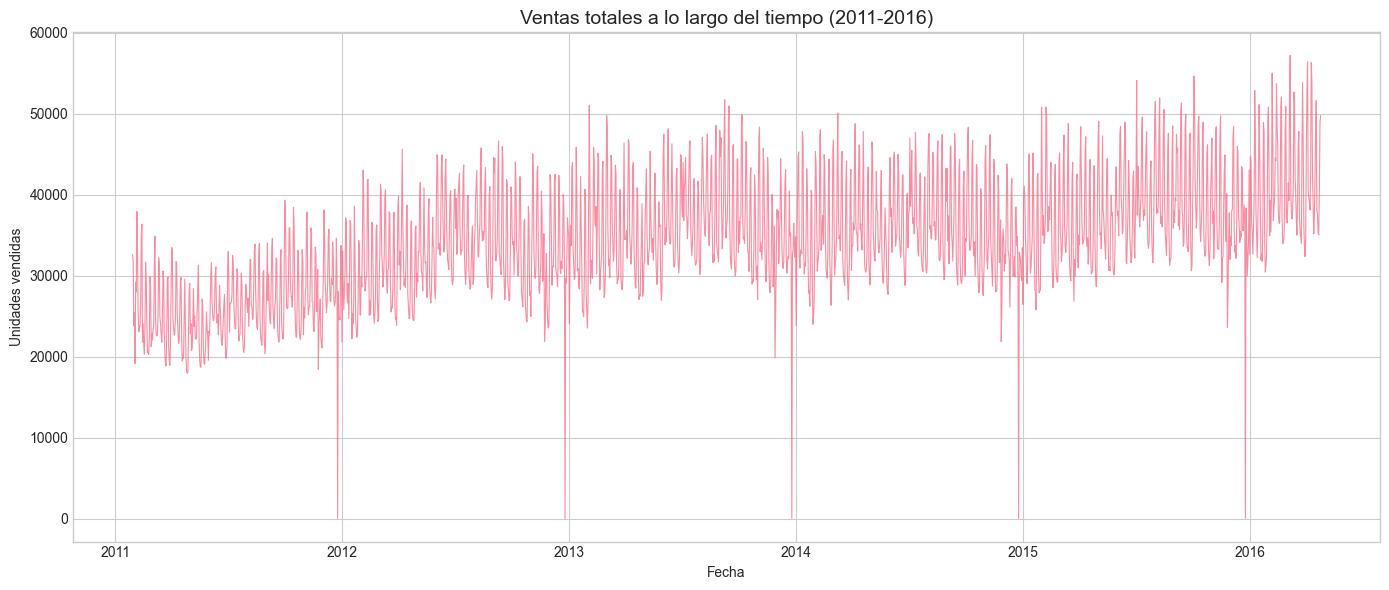

Fecha con más ventas: 2016-03-06 (57,218 unidades)
Fecha con menos ventas: 2012-12-25 (11 unidades)


In [36]:
# Ventas totales por fecha
ventas_por_fecha = df.groupby('date')['sales'].sum().reset_index()

# Gráfico de ventas a lo largo del tiempo
plt.figure(figsize=(14, 6))
plt.plot(ventas_por_fecha['date'], ventas_por_fecha['sales'], linewidth=0.8, alpha=0.8)
plt.title('Ventas totales a lo largo del tiempo (2011-2016)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Unidades vendidas')
plt.tight_layout()
plt.show()

print(f"Fecha con más ventas: {ventas_por_fecha.loc[ventas_por_fecha['sales'].idxmax(), 'date'].strftime('%Y-%m-%d')} ({ventas_por_fecha['sales'].max():,.0f} unidades)")
print(f"Fecha con menos ventas: {ventas_por_fecha.loc[ventas_por_fecha['sales'].idxmin(), 'date'].strftime('%Y-%m-%d')} ({ventas_por_fecha['sales'].min():,.0f} unidades)")

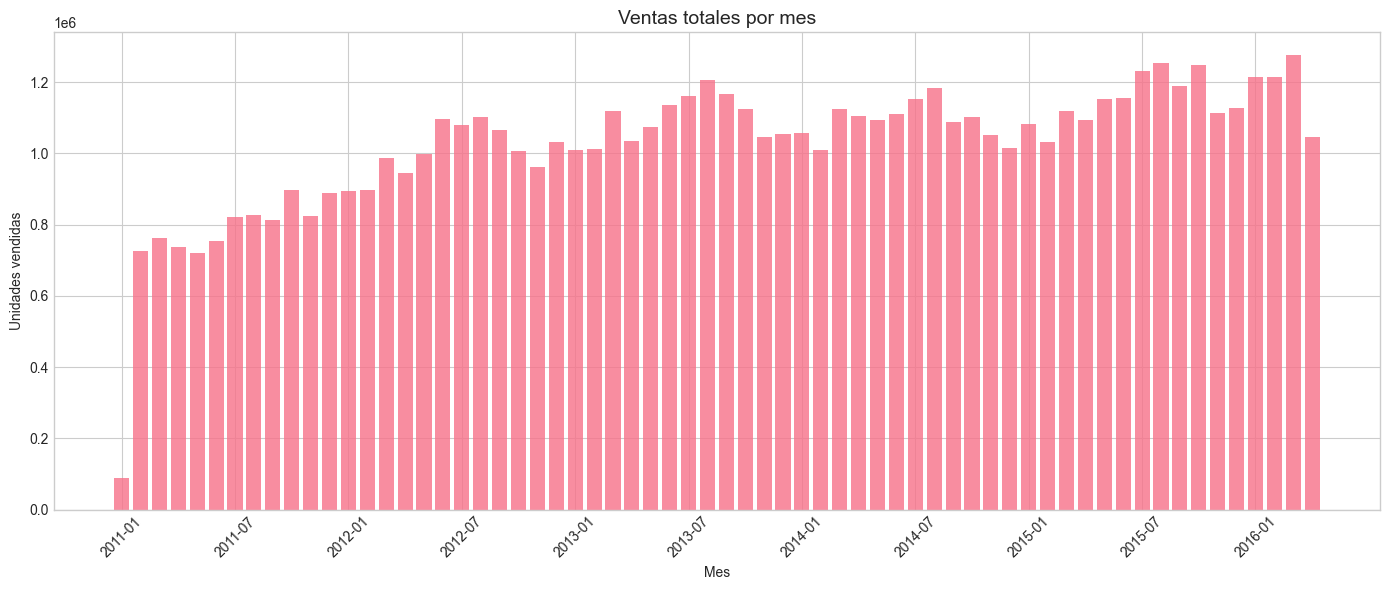

In [37]:
# Ventas por mes (agregado)
df['month'] = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M')

ventas_por_mes = df.groupby('year_month')['sales'].sum().reset_index()
ventas_por_mes['year_month'] = ventas_por_mes['year_month'].astype(str)

# Gráfico de ventas por mes
plt.figure(figsize=(14, 6))
plt.bar(range(len(ventas_por_mes)), ventas_por_mes['sales'], alpha=0.8)
plt.title('Ventas totales por mes', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Unidades vendidas')

# Mostrar solo algunas etiquetas para no saturar
tick_positions = range(0, len(ventas_por_mes), 6)
tick_labels = [ventas_por_mes['year_month'].iloc[i] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=45)

plt.tight_layout()
plt.show()

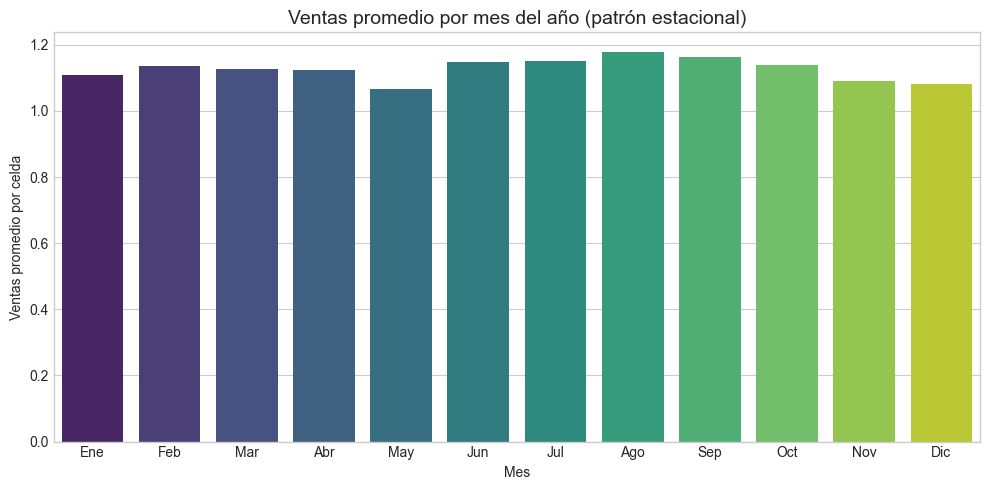

In [38]:
# Patrón estacional: ventas promedio por mes del año
ventas_por_mes_año = df.groupby('month')['sales'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='month', y='sales', data=ventas_por_mes_año, palette='viridis')
plt.title('Ventas promedio por mes del año (patrón estacional)', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Ventas promedio por celda')
plt.xticks(range(12), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                        'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.tight_layout()
plt.show()

## 9c. Visualización por dimensiones

Comparamos las ventas entre regiones, categorías y tiendas.

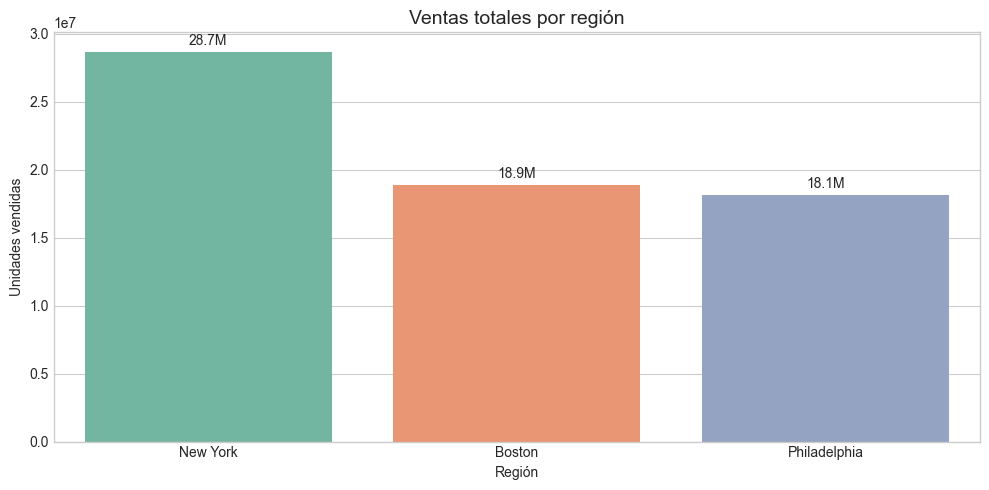

In [39]:
# Ventas por región
ventas_por_region = df.groupby('region')['sales'].sum().reset_index().sort_values('sales', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='region', y='sales', data=ventas_por_region, palette='Set2')
plt.title('Ventas totales por región', fontsize=14)
plt.xlabel('Región')
plt.ylabel('Unidades vendidas')

# Añadir etiquetas con valores
for i, v in enumerate(ventas_por_region['sales']):
    plt.text(i, v + 500000, f'{v/1e6:.1f}M', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

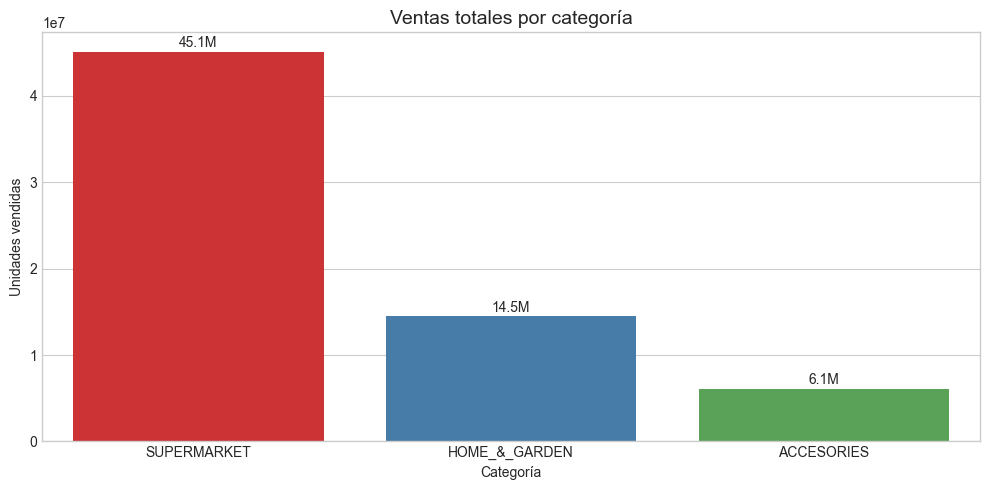


Porcentaje de ventas por categoría:
        category     sales  porcentaje
2    SUPERMARKET  45089939       68.60
1  HOME_&_GARDEN  14480670       22.00
0     ACCESORIES   6124800        9.30


In [40]:
# Ventas por categoría
ventas_por_categoria = df.groupby('category')['sales'].sum().reset_index().sort_values('sales', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='category', y='sales', data=ventas_por_categoria, palette='Set1')
plt.title('Ventas totales por categoría', fontsize=14)
plt.xlabel('Categoría')
plt.ylabel('Unidades vendidas')

# Añadir etiquetas con valores
for i, v in enumerate(ventas_por_categoria['sales']):
    plt.text(i, v + 500000, f'{v/1e6:.1f}M', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Porcentaje por categoría
print("\nPorcentaje de ventas por categoría:")
ventas_por_categoria['porcentaje'] = (ventas_por_categoria['sales'] / ventas_por_categoria['sales'].sum() * 100).round(1)
print(ventas_por_categoria)

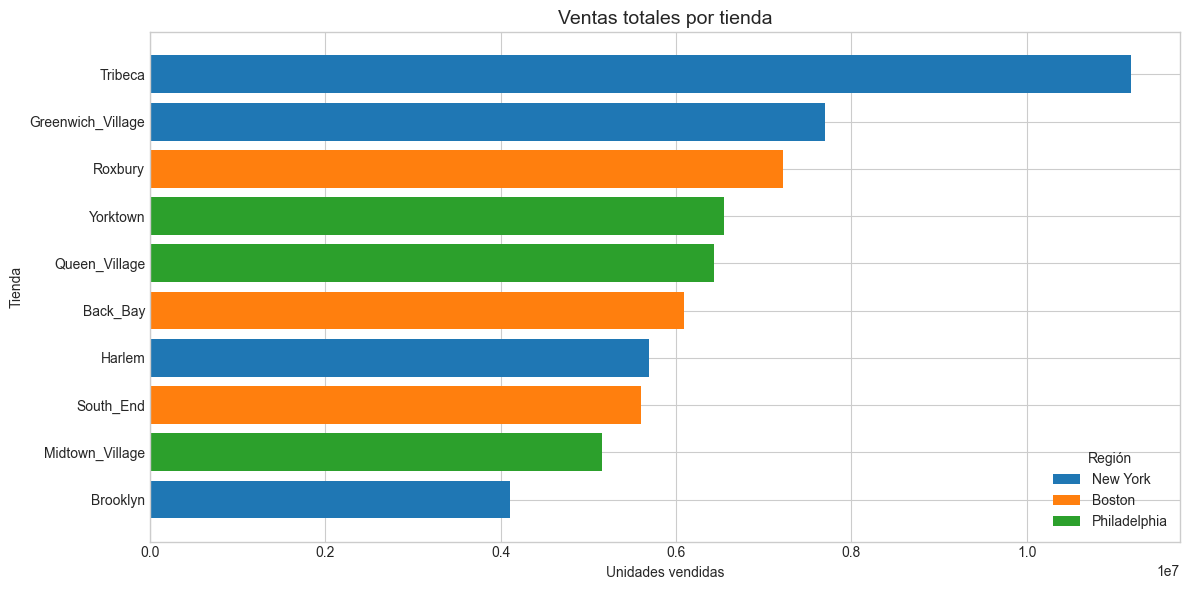

In [41]:
# Ventas por tienda
ventas_por_tienda = df.groupby(['store', 'region'])['sales'].sum().reset_index().sort_values('sales', ascending=True)

plt.figure(figsize=(12, 6))
colors = {'New York': '#1f77b4', 'Boston': '#ff7f0e', 'Philadelphia': '#2ca02c'}
bar_colors = [colors[r] for r in ventas_por_tienda['region']]

plt.barh(ventas_por_tienda['store'], ventas_por_tienda['sales'], color=bar_colors)
plt.title('Ventas totales por tienda', fontsize=14)
plt.xlabel('Unidades vendidas')
plt.ylabel('Tienda')

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[r], label=r) for r in colors.keys()]
plt.legend(handles=legend_elements, title='Región', loc='lower right')

plt.tight_layout()
plt.show()

## 9d. Comparación estadística entre regiones

Realizamos un test ANOVA para determinar si existen diferencias significativas en las ventas entre regiones.

In [42]:
# Preparar datos para ANOVA: ventas diarias por región
ventas_diarias_region = df.groupby(['date', 'region'])['sales'].sum().reset_index()

# Separar por región
ventas_ny = ventas_diarias_region[ventas_diarias_region['region'] == 'New York']['sales']
ventas_boston = ventas_diarias_region[ventas_diarias_region['region'] == 'Boston']['sales']
ventas_phila = ventas_diarias_region[ventas_diarias_region['region'] == 'Philadelphia']['sales']

# Test ANOVA
resultado_anova = f_oneway(ventas_ny, ventas_boston, ventas_phila)

print("="*60)
print("TEST ANOVA: COMPARACIÓN DE VENTAS ENTRE REGIONES")
print("="*60)
print(f"Estadístico F: {resultado_anova.statistic:.2f}")
print(f"P-valor: {resultado_anova.pvalue:.2e}")

nivel_significancia = 0.05
if resultado_anova.pvalue < nivel_significancia:
    print(f"\n✓ Existen diferencias significativas entre regiones (p < {nivel_significancia})")
else:
    print(f"\n✗ No se encontraron diferencias significativas (p >= {nivel_significancia})")

TEST ANOVA: COMPARACIÓN DE VENTAS ENTRE REGIONES
Estadístico F: 2578.63
P-valor: 0.00e+00

✓ Existen diferencias significativas entre regiones (p < 0.05)


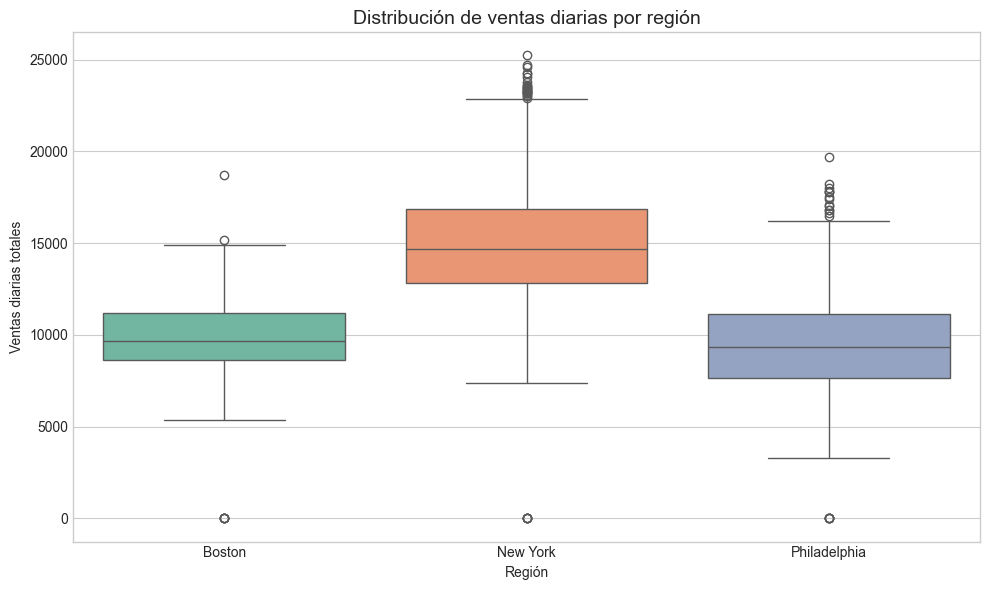


Estadísticas de ventas diarias por región:
               count     mean     std  min      25%      50%      75%      max
region                                                                        
Boston       1913.00  9879.00 1965.00 2.00  8608.00  9647.00 11171.00 18733.00
New York     1913.00 14990.00 3257.00 5.00 12834.00 14678.00 16846.00 25224.00
Philadelphia 1913.00  9472.00 2563.00 1.00  7666.00  9327.00 11139.00 19669.00


In [43]:
# Boxplot de comparación entre regiones
plt.figure(figsize=(10, 6))
sns.boxplot(x='region', y='sales', data=ventas_diarias_region, palette='Set2')
plt.title('Distribución de ventas diarias por región', fontsize=14)
plt.xlabel('Región')
plt.ylabel('Ventas diarias totales')
plt.tight_layout()
plt.show()

# Estadísticas descriptivas por región
print("\nEstadísticas de ventas diarias por región:")
print(ventas_diarias_region.groupby('region')['sales'].describe().round(0))

## 9e. Patrones semanales: Heatmap día de semana vs mes

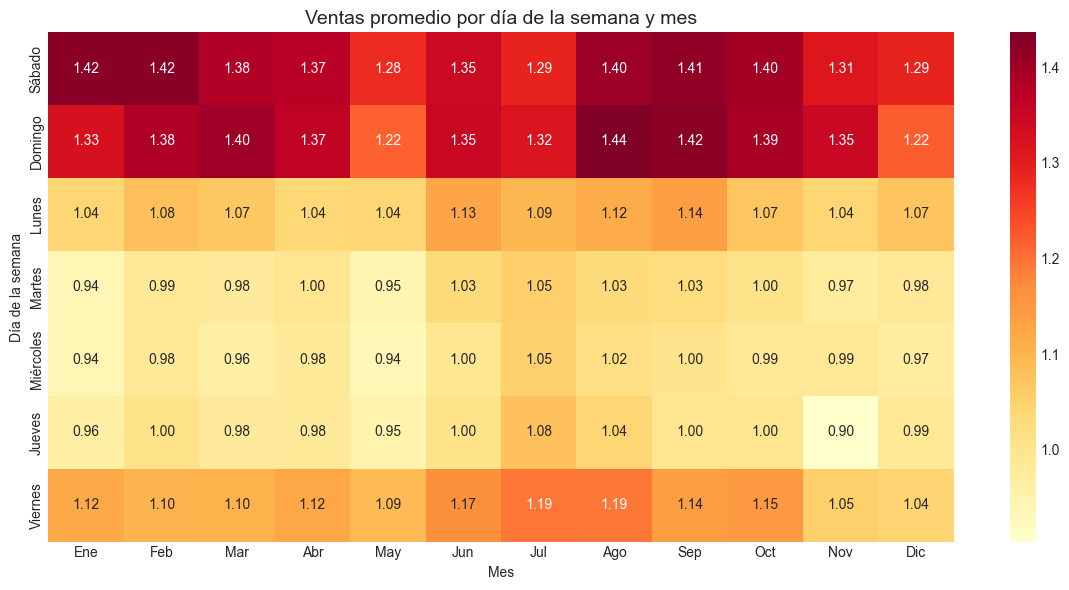

In [44]:
# Crear pivot table: ventas promedio por día de semana y mes
heatmap_data = df.groupby(['weekday_int', 'month'])['sales'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='weekday_int', columns='month', values='sales')

# Ordenar días de la semana (1=Sábado según el enunciado)
dias_semana = ['Sábado', 'Domingo', 'Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes']
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_pivot, 
            annot=True, 
            fmt='.2f', 
            cmap='YlOrRd',
            xticklabels=meses,
            yticklabels=dias_semana)
plt.title('Ventas promedio por día de la semana y mes', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Día de la semana')
plt.tight_layout()
plt.show()

## 9f. Top 10 productos más vendidos

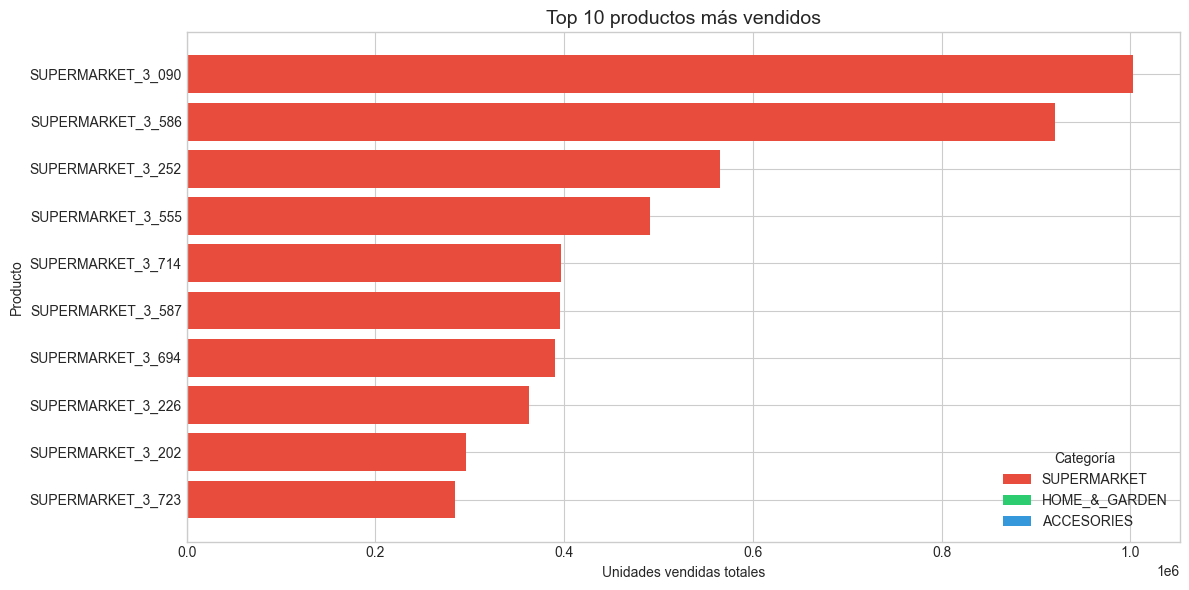


Detalle Top 10 productos:
             item    category   sales
SUPERMARKET_3_090 SUPERMARKET 1002529
SUPERMARKET_3_586 SUPERMARKET  920242
SUPERMARKET_3_252 SUPERMARKET  565299
SUPERMARKET_3_555 SUPERMARKET  491287
SUPERMARKET_3_714 SUPERMARKET  396172
SUPERMARKET_3_587 SUPERMARKET  396119
SUPERMARKET_3_694 SUPERMARKET  390001
SUPERMARKET_3_226 SUPERMARKET  363082
SUPERMARKET_3_202 SUPERMARKET  295689
SUPERMARKET_3_723 SUPERMARKET  284333


In [45]:
# Top 10 productos por ventas totales
top_productos = df.groupby(['item', 'category'])['sales'].sum().reset_index()
top_productos = top_productos.nlargest(10, 'sales')

plt.figure(figsize=(12, 6))
colors_cat = {'SUPERMARKET': '#e74c3c', 'HOME_&_GARDEN': '#2ecc71', 'ACCESORIES': '#3498db'}
bar_colors = [colors_cat[c] for c in top_productos['category']]

plt.barh(range(len(top_productos)), top_productos['sales'], color=bar_colors)
plt.yticks(range(len(top_productos)), top_productos['item'])
plt.title('Top 10 productos más vendidos', fontsize=14)
plt.xlabel('Unidades vendidas totales')
plt.ylabel('Producto')

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_cat[c], label=c) for c in colors_cat.keys()]
plt.legend(handles=legend_elements, title='Categoría', loc='lower right')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nDetalle Top 10 productos:")
print(top_productos.to_string(index=False))

## 9g. Distribución de precios

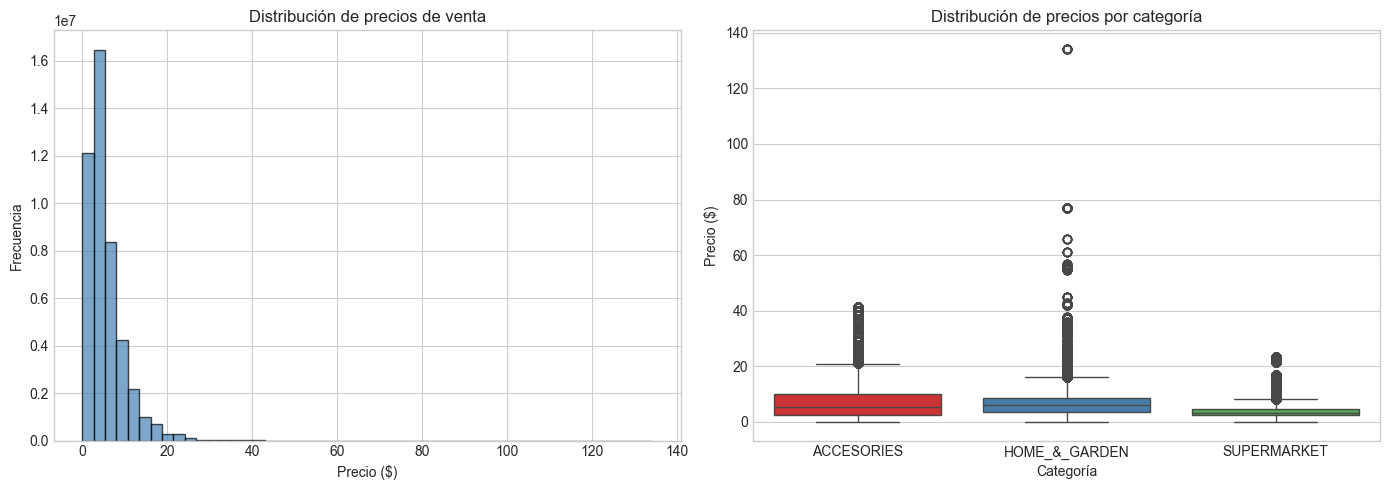


Estadísticas de precios por categoría:
                    count  mean  std  min  25%  50%  75%    max
category                                                       
ACCESORIES     8598965.00  7.08 6.40 0.01 2.62 5.28 9.94  41.20
HOME_&_GARDEN 15908320.00  6.83 4.21 0.01 3.72 6.18 8.71 134.15
SUPERMARKET   21287356.00  3.90 2.56 0.01 2.38 3.22 4.76  23.38


In [46]:
# Distribución de precios (excluyendo nulos)
precios_validos = df[df['sell_price'].notna()]['sell_price']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(precios_validos, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Precio ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de precios de venta')

# Boxplot por categoría
df_precios = df[df['sell_price'].notna()]
sns.boxplot(x='category', y='sell_price', data=df_precios, ax=axes[1], palette='Set1')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Precio ($)')
axes[1].set_title('Distribución de precios por categoría')

plt.tight_layout()
plt.show()

print("\nEstadísticas de precios por categoría:")
print(df_precios.groupby('category')['sell_price'].describe().round(2))

## 9h. Efecto de eventos en ventas

Comparamos las ventas en días con eventos especiales vs días normales.

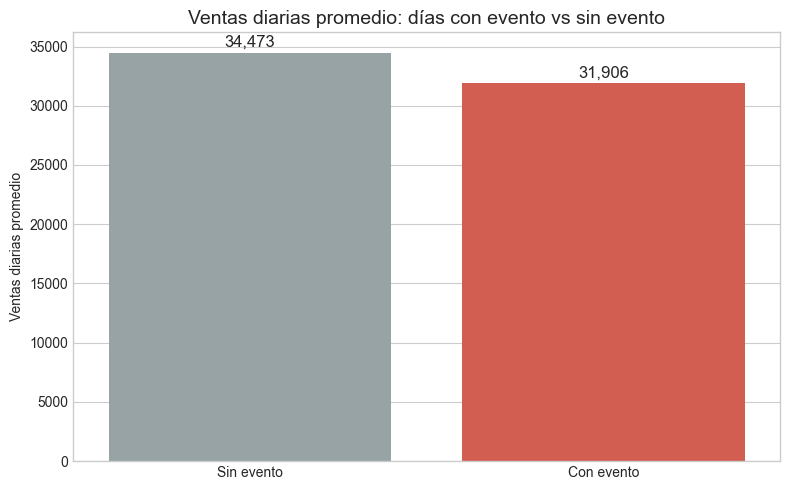

Ventas promedio sin evento: 34,473
Ventas promedio con evento: 31,906
Diferencia: -7.4%


In [47]:
# Crear columna binaria: tiene evento o no
df['tiene_evento'] = df['event'].notna()

# Ventas promedio por día con/sin evento
ventas_por_evento = df.groupby(['date', 'tiene_evento'])['sales'].sum().reset_index()
comparacion_eventos = ventas_por_evento.groupby('tiene_evento')['sales'].mean().reset_index()
comparacion_eventos['tiene_evento'] = comparacion_eventos['tiene_evento'].map({True: 'Con evento', False: 'Sin evento'})

plt.figure(figsize=(8, 5))
sns.barplot(x='tiene_evento', y='sales', data=comparacion_eventos, palette=['#95a5a6', '#e74c3c'])
plt.title('Ventas diarias promedio: días con evento vs sin evento', fontsize=14)
plt.xlabel('')
plt.ylabel('Ventas diarias promedio')

# Añadir etiquetas
for i, v in enumerate(comparacion_eventos['sales']):
    plt.text(i, v + 500, f'{v:,.0f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

# Calcular diferencia porcentual
ventas_sin_evento = comparacion_eventos[comparacion_eventos['tiene_evento'] == 'Sin evento']['sales'].values[0]
ventas_con_evento = comparacion_eventos[comparacion_eventos['tiene_evento'] == 'Con evento']['sales'].values[0]
diferencia_pct = ((ventas_con_evento - ventas_sin_evento) / ventas_sin_evento) * 100

print(f"Ventas promedio sin evento: {ventas_sin_evento:,.0f}")
print(f"Ventas promedio con evento: {ventas_con_evento:,.0f}")
print(f"Diferencia: {diferencia_pct:+.1f}%")

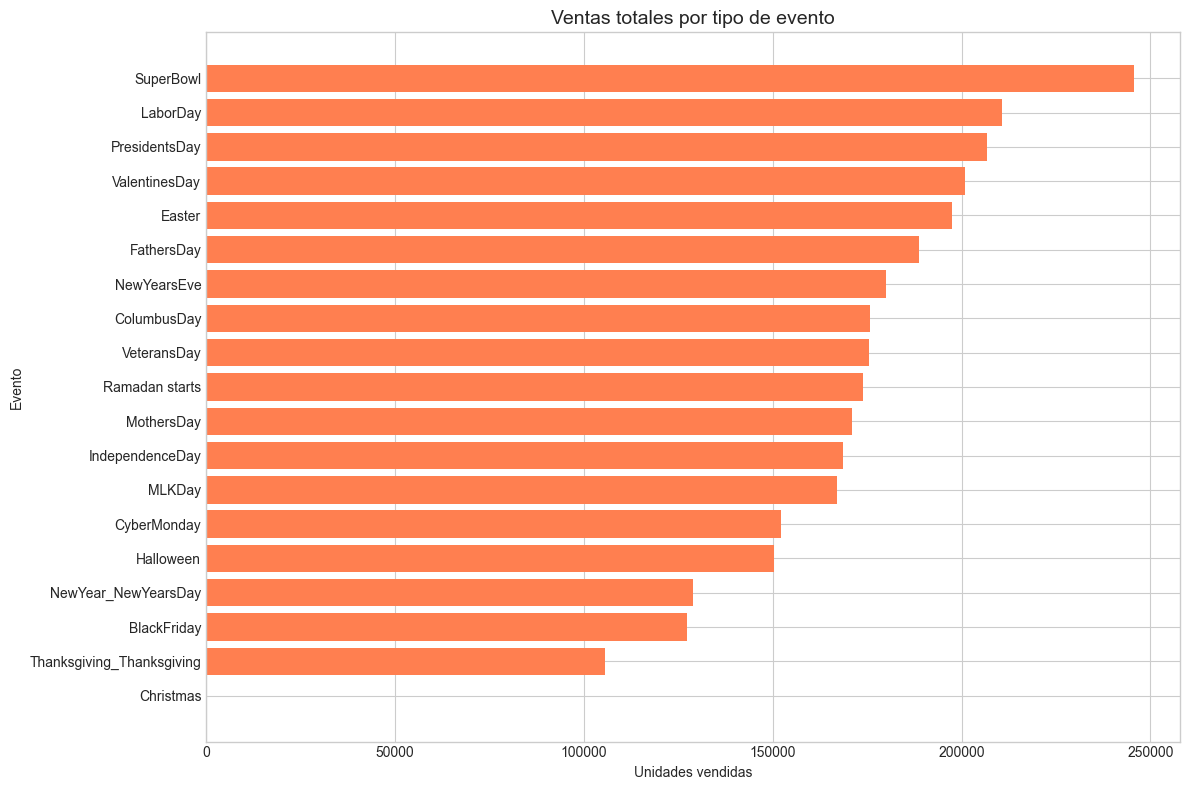


Ventas por evento (ordenado de mayor a menor):
                    event  sales
                SuperBowl 245544
                 LaborDay 210773
            PresidentsDay 206678
            ValentinesDay 200974
                   Easter 197588
               FathersDay 188742
              NewYearsEve 180107
              ColumbusDay 175824
              VeteransDay 175594
           Ramadan starts 173898
               MothersDay 171057
          IndependenceDay 168554
                   MLKDay 166893
              CyberMonday 152262
                Halloween 150297
      NewYear_NewYearsDay 128842
              BlackFriday 127429
Thanksgiving_Thanksgiving 105650
                Christmas     78


In [48]:
# Ventas por tipo de evento
ventas_por_tipo_evento = df[df['event'].notna()].groupby('event')['sales'].sum().reset_index()
ventas_por_tipo_evento = ventas_por_tipo_evento.sort_values('sales', ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(ventas_por_tipo_evento['event'], ventas_por_tipo_evento['sales'], color='coral')
plt.title('Ventas totales por tipo de evento', fontsize=14)
plt.xlabel('Unidades vendidas')
plt.ylabel('Evento')
plt.tight_layout()
plt.show()

print("\nVentas por evento (ordenado de mayor a menor):")
print(ventas_por_tipo_evento.sort_values('sales', ascending=False).to_string(index=False))

In [49]:
# Limpiar columnas temporales creadas para visualización
df = df.drop(columns=['month', 'year_month', 'tiene_evento'])

print("Columnas temporales eliminadas")
print(f"Columnas finales del dataset: {df.columns.tolist()}")

Columnas temporales eliminadas
Columnas finales del dataset: ['id', 'item', 'category', 'department', 'store', 'store_code', 'region', 'd', 'sales', 'date', 'weekday', 'weekday_int', 'event', 'year', 'week', 'yearweek', 'sell_price']


## 10. Guardado del dataset procesado

Guardamos el dataset unificado en la carpeta `data_dsmarket/processed/` para usar en notebooks posteriores.

In [50]:
# Ruta de guardado
output_path = '/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/processed/sales_processed.csv'

# Guardar csv
df.to_csv(output_path, index=False)

print(f"Dataset guardado en: {output_path}")
print(f"Tamaño: {df.shape[0]:,} filas x {df.shape[1]} columnas")

Dataset guardado en: /Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/processed/sales_processed.csv
Tamaño: 58,327,370 filas x 17 columnas


In [51]:
# Verificar que se puede leer correctamente
df_test = pd.read_csv(output_path)
print(f"Verificación de lectura: {df_test.shape[0]:,} filas x {df_test.shape[1]} columnas")
print("Guardado verificado correctamente!")

Verificación de lectura: 58,327,370 filas x 17 columnas
Guardado verificado correctamente!
